<a href="https://colab.research.google.com/github/MishaE-e/ml_fmi/blob/main/5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Набор данных: https://archive.ics.uci.edu/dataset/837/product+classification+and+clustering

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA, FastICA, KernelPCA
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, v_measure_score
from sklearn.neighbors import NearestNeighbors

2. Загрузка данных

In [ ]:
df = pd.read_csv('pricerunner_aggregate.csv')

In [ ]:
df

,Product ID,Product Title,Merchant ID,Cluster ID,Cluster Label,Category ID,Category Label
0,1,apple iphone 8 plus 64gb silver,1,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
1,2,apple iphone 8 plus 64 gb spacegrau,2,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
3,4,apple iphone 8 plus 64gb space grey,4,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
...,...,...,...,...,...,...,...
35306,47350,smeg fab28 60cm retro style right hand hinge f...,59,47517,Smeg FAB28 Cream,2623,Fridges
35307,47351,smeg fab28 60cm retro style left hand hinge fr...,59,47518,Smeg FAB28 Red,2623,Fridges
35308,47352,smeg fab28 60cm retro style left hand hinge fr...,59,47519,Smeg FAB28 Pink,2623,Fridges
35309,47355,candy 60cm built under larder fridge cru160nek,125,47524,Candy CRU16.0,2623,Fridges


3. Подготовка данных

In [ ]:
features = ['Product ID', ' Merchant ID', ' Cluster ID']
X = df[features].copy()

In [ ]:
le = LabelEncoder()
y_true = le.fit_transform(df[' Cluster Label'])

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

3. Методы для снижения размерности

PCA

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Суммарно: {sum(pca.explained_variance_ratio_):.4f}")


PC1: 0.7550
PC2: 0.2151
Суммарно: 0.9702


Text(0, 0.5, 'Вторая главная компонента')

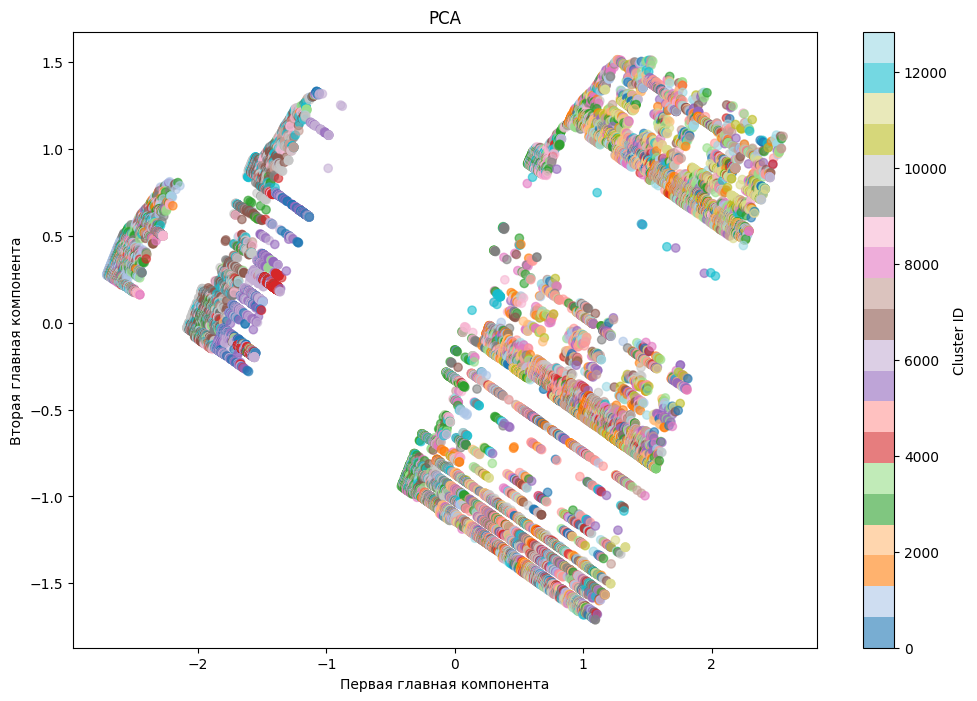

In [ ]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='tab20', alpha=0.6)
plt.colorbar(scatter, label='Cluster ID')
plt.title('PCA')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')

ICA

In [ ]:
ica = FastICA(n_components=2, random_state=42)
X_ica = ica.fit_transform(X_scaled)

Text(0, 0.5, 'Вторая независимая компонента')

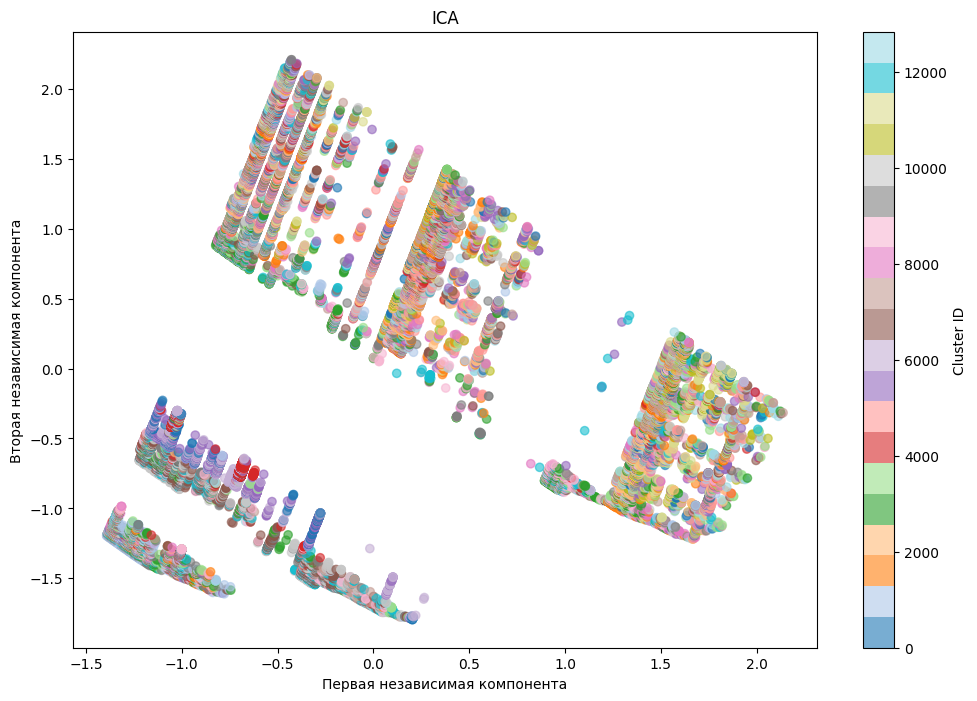

In [ ]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_ica[:, 0], X_ica[:, 1], c=y_true, cmap='tab20', alpha=0.6)
plt.colorbar(scatter, label='Cluster ID')
plt.title('ICA')
plt.xlabel('Первая независимая компонента')
plt.ylabel('Вторая независимая компонента')

Kernel PCA

In [ ]:
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=0.1, random_state=42)
X_kpca = kpca.fit_transform(X_scaled)

Text(0, 0.5, 'Вторая компонента Kernel PCA')

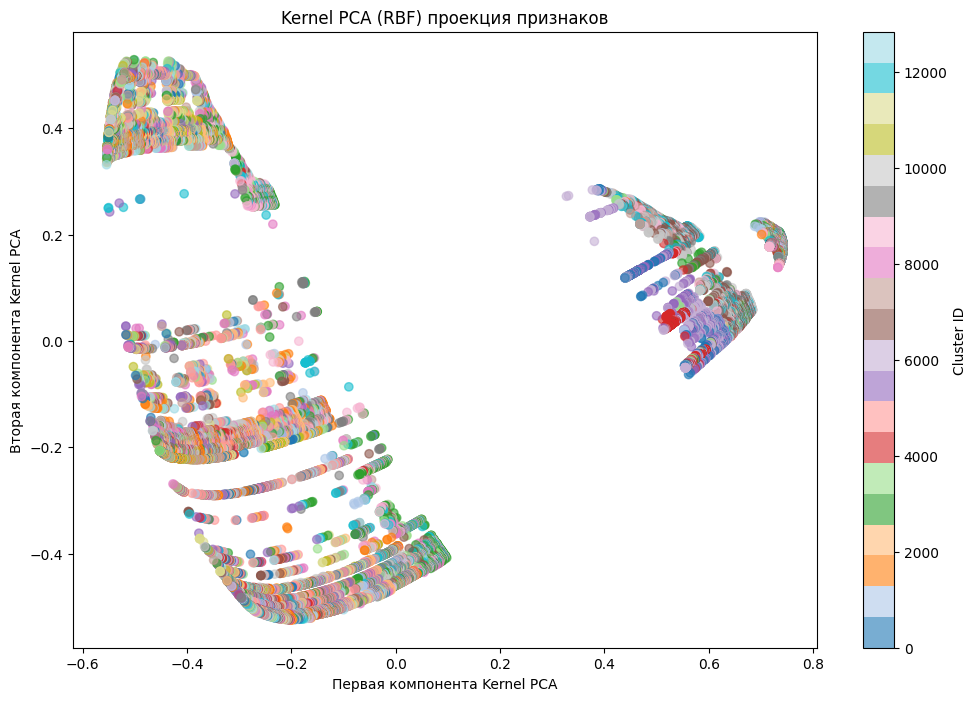

In [ ]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y_true, cmap='tab20', alpha=0.6)
plt.colorbar(scatter, label='Cluster ID')
plt.title('Kernel PCA (RBF) проекция признаков')
plt.xlabel('Первая компонента Kernel PCA')
plt.ylabel('Вторая компонента Kernel PCA')

 t-SNE

In [ ]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [ ]:
print(f"Расхождение после оптимизации: {tsne.kl_divergence_:.4f}")
print(f"Количество итераций: {tsne.n_iter_}")

Расхождение после оптимизации: 0.6335
Количество итераций: 999


Text(0, 0.5, 'Вторая компонента t-SNE')

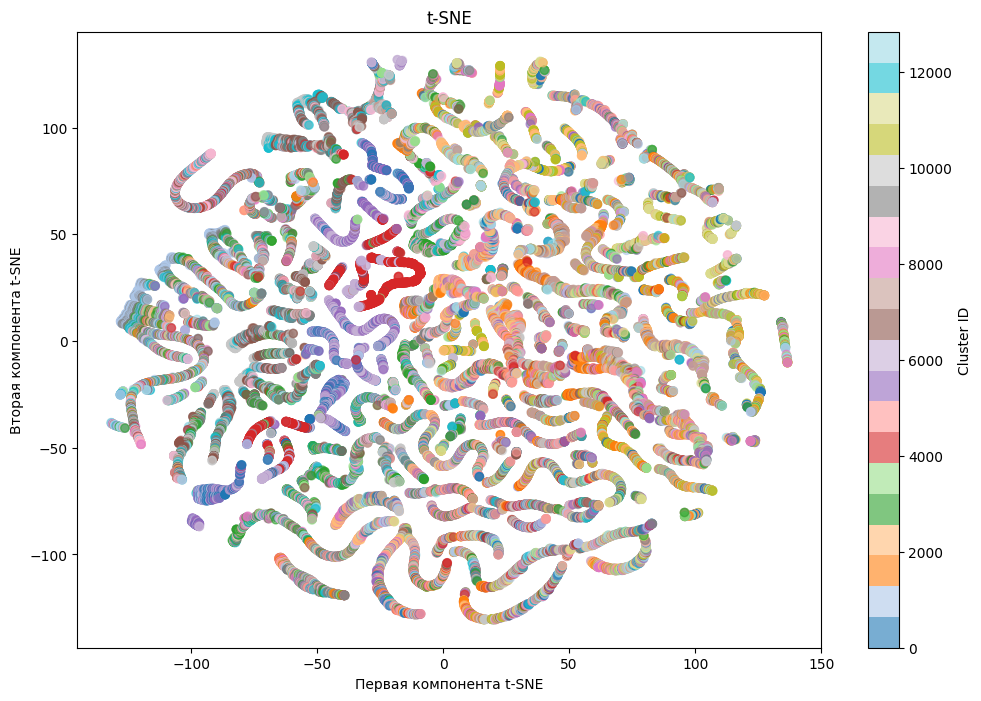

In [ ]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_true, cmap='tab20', alpha=0.6)
plt.colorbar(scatter, label='Cluster ID')
plt.title('t-SNE')
plt.xlabel('Первая компонента t-SNE')
plt.ylabel('Вторая компонента t-SNE')

4. Кластеризация и поиск выбросов с помощью DBSCAN

Оптимизация DBSCAN

In [ ]:
min_samples = 3
knn = NearestNeighbors(n_neighbors=min_samples, metric='euclidean')
knn.fit(X_scaled)

NearestNeighbors(metric='euclidean', n_neighbors=3)

In [ ]:
distances, indices = knn.kneighbors(X_scaled)
k_distances = distances[:, -1]
k_distances_sorted = np.sort(k_distances)

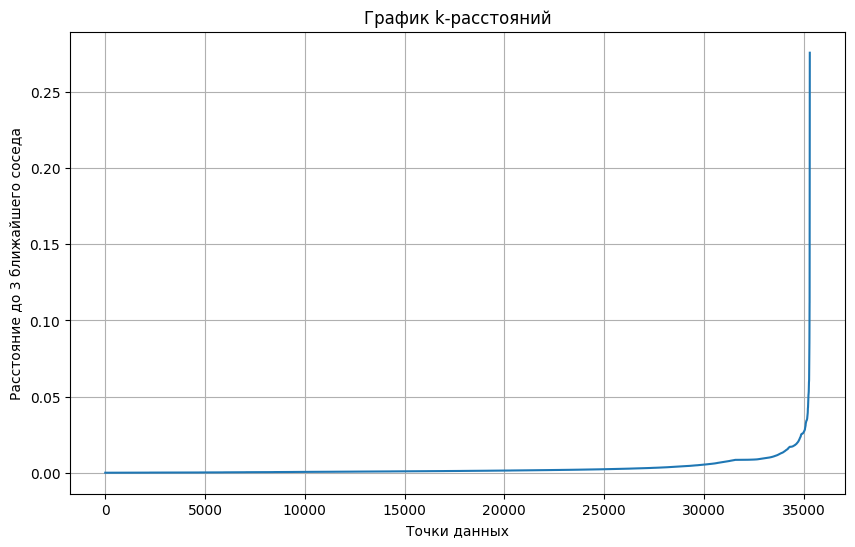

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(len(k_distances_sorted)), k_distances_sorted)
plt.xlabel('Точки данных')
plt.ylabel(f'Расстояние до {min_samples} ближайшего соседа')
plt.title('График k-расстояний')
plt.grid(True)

In [ ]:
eps_value = 1.5
print(f"Выбранное значение eps: {eps_value}")

Выбранное значение eps: 1.5


Применение DBSCAN

In [ ]:
dbscan = DBSCAN(eps=eps_value, min_samples=min_samples)
y_dbscan = dbscan.fit_predict(X_scaled)

In [ ]:
n_clusters = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)
n_noise = list(y_dbscan).count(-1)

In [ ]:
print(f"DBSCAN результаты:")
print(f"  - Оцененное количество кластеров: {n_clusters}")
print(f"  - Количество шумовых точек (выбросов): {n_noise}")
print(f"  - Процент выбросов: {n_noise/len(y_dbscan)*100:.2f}%")

DBSCAN результаты:
  - Оцененное количество кластеров: 2
  - Количество шумовых точек (выбросов): 0
  - Процент выбросов: 0.00%


In [ ]:
v_measure = v_measure_score(y_true, y_dbscan)
print(f"  - V-measure (сравнение с Cluster Label): {v_measure:.4f}")

  - V-measure (сравнение с Cluster Label): 0.1290


Text(0, 0.5, 'PC2')

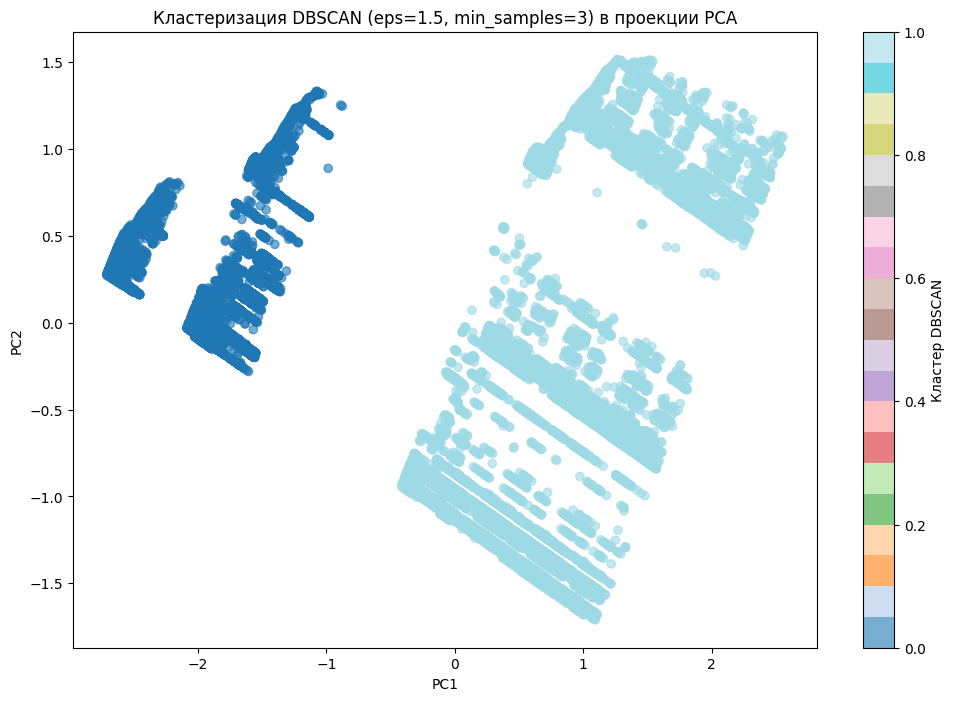

In [ ]:
X_pca_for_dbscan = PCA(n_components=2).fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca_for_dbscan[:, 0], X_pca_for_dbscan[:, 1],
                     c=y_dbscan, cmap='tab20', alpha=0.6)
plt.colorbar(scatter, label='Кластер DBSCAN')
plt.title(f'Кластеризация DBSCAN (eps={eps_value}, min_samples={min_samples}) в проекции PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')